# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
print(f"Amostras das primeiras linhas: {df.head()}")

Amostras das primeiras linhas:    Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0              8          0                    38               0   
1              0          0                    39               0   
2             10          0                    37               0   
3             10          0                    38               0   
4              3          0                    38               0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2         

In [5]:
linhas, colunas = df.shape
print(f"\nQuantidade de amostras e atributos (dimensões): Linhas {linhas} x {colunas} Colunas")


Quantidade de amostras e atributos (dimensões): Linhas 3150 x 14 Colunas


In [6]:
TARGET_COLUMN = "Churn" # preenchido :)
print(f"\nVariável alvo: {df[TARGET_COLUMN]}")
print(f"\nValores únicos da variável alvo: {df[TARGET_COLUMN].unique()}")


Variável alvo: 0       0
1       0
2       0
3       0
4       0
       ..
3145    0
3146    0
3147    0
3148    0
3149    1
Name: Churn, Length: 3150, dtype: int64

Valores únicos da variável alvo: [0 1]


O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

/tmp/ipykernel_13783/3319240295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COLUMN, palette="Set2")


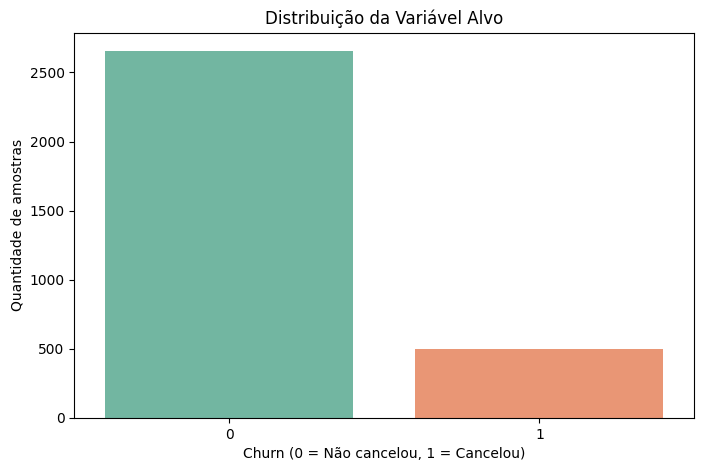

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COLUMN, palette="Set2")


plt.title('Distribuição da Variável Alvo')
plt.xlabel('Churn (0 = Não cancelou, 1 = Cancelou)')
plt.ylabel('Quantidade de amostras')

plt.show()

A partir do gráfico de barras da variável alvo, podemos observar que o dataset é desbalanceado, pois há uma diferença expressiva entre as classes — a majoritária representa aproximadamente 5x mais amostras que a minoritária

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

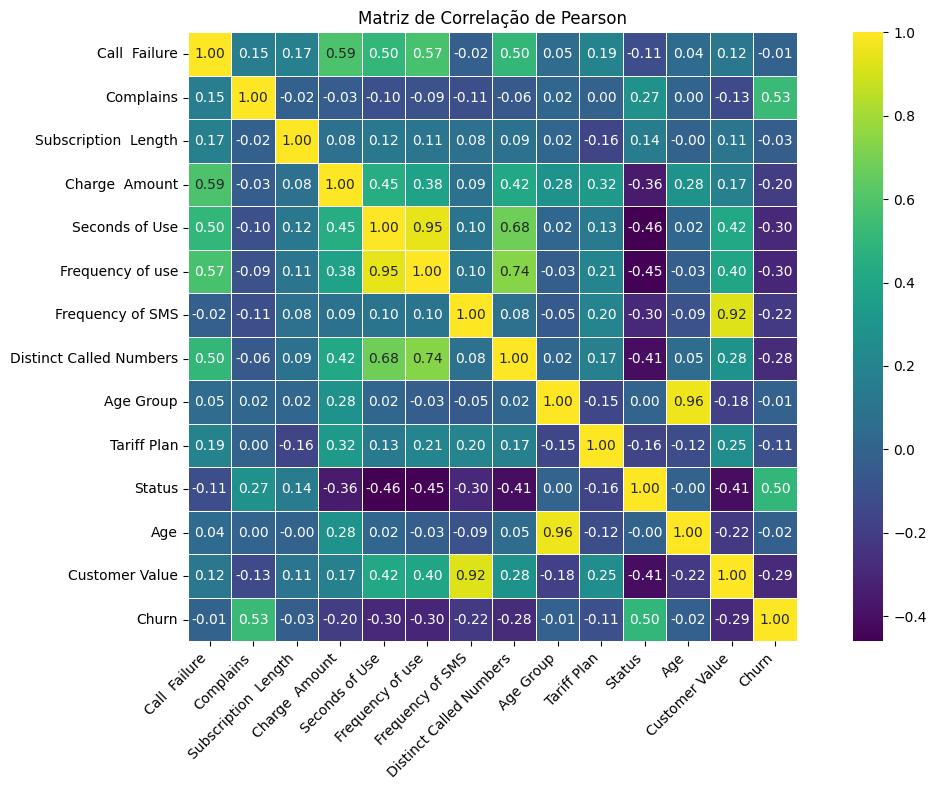

In [8]:
corr_mat = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

# Observações: annot coloca o numero dentro da celula, fmt formata pra 2 casas,
# linew adiciona a boridinha na celula, square deixa proporção quadarada
sns.heatmap(corr_mat, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5, square=True)

plt.title('Matriz de Correlação de Pearson')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
print("Correlação dos atributos com a variável alvo (Churn):\n")
print(corr_mat[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)) # Obs: removendo a auto relação e ordenando

Correlação dos atributos com a variável alvo (Churn):

Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


Os atributos que mais possuem relação com a variável alvo é 'complains', o que indica que os clientes tendem a reclamar do serviço quando cancelam o mesmo.

Enquanto atributos como 'Frequency of use' indicam uma relação inversa, sugerindo uma tendência a não cancelar

Os atributos com correlações mais próximas de zero, como Call Failure, têm menor relevância preditiva para essa análise.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

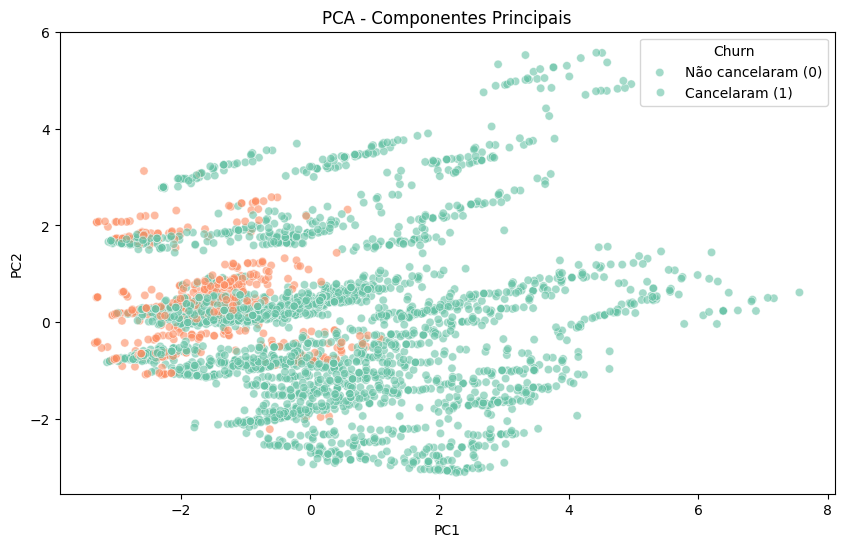

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
df_pca[TARGET_COLUMN] = y.values

plt.figure(figsize=(10, 6))

# Observações: hue deixa a cor por classe, alpha menor para ver sobreposições
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=TARGET_COLUMN, palette='Set2', alpha = 0.6)

plt.title('PCA - Componentes Principais')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title="Churn", labels=["Não cancelaram (0)", "Cancelaram (1)"])
plt.show()


O gráfico de dispersão revela uma separação parcial entre as classes. Os clientes cancelaram concentram-se predominantemente na região de PC1 baixo (entre -3 e +1), enquanto os clientes que não cancelaram (classe 0) distribuem-se por toda a extensão do eixo PC1, ocupando exclusivamente as regiões com PC1 > 2. Contudo, há sobreposição considerável na região esquerda do gráfico, onde ambas as classes coexistem. Isso indica que as duas primeiras componentes principais não são suficientes para separar linearmente as classes, sugerindo que o problema exige um classificador com fronteira de decisão não-linear ou que as demais componentes (não visualizadas) contribuem para a discriminação entre os grupos

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

É necessário aplicar a padronização para que os atributos com maior escala não afetem no treinamento do modelo negativamente, enquanto o fit deve ser aplicado apenas no conjunto de treinamento para que não haja vazamento de dados, levando ao overfitting do modelo

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

print(f"Número de iterações: {model.n_iter_}")

Número de iterações: [42]


A partir dos dados obtidos o modelo teve uma boa convergência, o que é indicado pelo número de iterações realizadas por ele, que se comparados com o máximo, o qual é 100 iterações por padrão na biblioteca, foi menor.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [13]:
y_prob = model.predict_proba(x_test_scaled)

df_probs = pd.DataFrame(y_prob,columns=["P(Não cancelaram = 0)", "P(Cancelaram = 1)"])
print("Primeiras probabilidades previstas:")
print(df_probs.head(10))

Primeiras probabilidades previstas:
   P(Não cancelaram = 0)  P(Cancelaram = 1)
0               0.998819           0.001181
1               0.999954           0.000046
2               0.974259           0.025741
3               0.999518           0.000482
4               0.998645           0.001355
5               0.997155           0.002845
6               0.991459           0.008541
7               0.991455           0.008545
8               0.987025           0.012975
9               0.590190           0.409810


Podemos observar pela amostra de 10 das probabilidades que as probabilidades indicam um modelo com previsões de alta confiança, com poucos casos onde a confiança é incerta, visto que a maior parte das probabilidades é, pelo menos, superior a 60% seja para uma classe ou outra.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [14]:
limiar05 = (y_prob[:, 1] >= 0.5).astype(int)
limiar07 = (y_prob[:, 1] >= 0.7).astype(int)

print(f"Classificação com limiar de 0.5: {limiar05.sum()}")
print(f"Classificação com limiar de 0.7: {limiar07.sum()}")

Classificação com limiar de 0.5: 60
Classificação com limiar de 0.7: 42


Podemos observar que o resultado para os dois valores diferentes de limiar faz com que um número maior ou menor de amostras sejam consideradas como Churn.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [15]:
for limiar, nome in zip([limiar05, limiar07], ["0.5", "0.7"]):
  print(f"\nAcurácia com limiar de {nome}: {accuracy_score(y_test, limiar)}")
  print(f"Precisão com limiar de {nome}: {precision_score(y_test, limiar)}")
  print(f"Recall com limiar de {nome}: {recall_score(y_test, limiar)}")
  print(f"F1-score com limiar de {nome}: {f1_score(y_test, limiar)}")
  print(f"Matriz de confusão com limiar de {nome}:\n{confusion_matrix(y_test, limiar)}")


Acurácia com limiar de 0.5: 0.8698412698412699
Precisão com limiar de 0.5: 0.7333333333333333
Recall com limiar de 0.5: 0.4
F1-score com limiar de 0.5: 0.5176470588235295
Matriz de confusão com limiar de 0.5:
[[504  16]
 [ 66  44]]

Acurácia com limiar de 0.7: 0.873015873015873
Precisão com limiar de 0.7: 0.8571428571428571
Recall com limiar de 0.7: 0.32727272727272727
F1-score com limiar de 0.7: 0.47368421052631576
Matriz de confusão com limiar de 0.7:
[[514   6]
 [ 74  36]]


Podemos observar com a diferença de limiar que todos os dados de métricas de precisão melhoraram com o aumento do limiar, melhorando a capacidade preditiva do modelo. Algo que podemos observar também na matriz de confusão, que houve menos casos de erros.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

In [16]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [17]:
print(f"Amostras das primeiras linhas do dataframe: {df.head()}")

Amostras das primeiras linhas do dataframe:         Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
250728       3351     206     27                               726   
246788       2732     129      7                               212   
407714       2572      24      9                               201   
25713        2824      69     13                               417   
21820        2529      84      5                               120   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
250728                             124                             3813   
246788                               1                             1082   
407714                              25                              957   
25713                               39                             3223   
21820                                9                             1092   

        Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
250728            192       

In [18]:
print(f"Dimensões do dataframe: {df.shape}")

Dimensões do dataframe: (58101, 55)


In [19]:
TARGET_COLUMN = "Cover_Type" # preencher

print(f"Variável alvo: {df[TARGET_COLUMN]}")
print(f"Valores únicos da variável alvo: {df[TARGET_COLUMN].unique()}")

Variável alvo: 250728    1
246788    2
407714    2
25713     2
21820     2
         ..
482174    1
566011    2
268113    3
407382    1
491461    2
Name: Cover_Type, Length: 58101, dtype: int64
Valores únicos da variável alvo: [1 2 3 5 6 7 4]


O dataset possui 58101 amostras e 55 atributos (incluindo a variável alvo), sendo cover type a variável alvo; trata-se de um problema de classificação multilabel, pois essa variável assume agora, diferentemente do anterior, 7 valores diferentes

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

/tmp/ipykernel_13783/2689085046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COLUMN, palette="Set2")


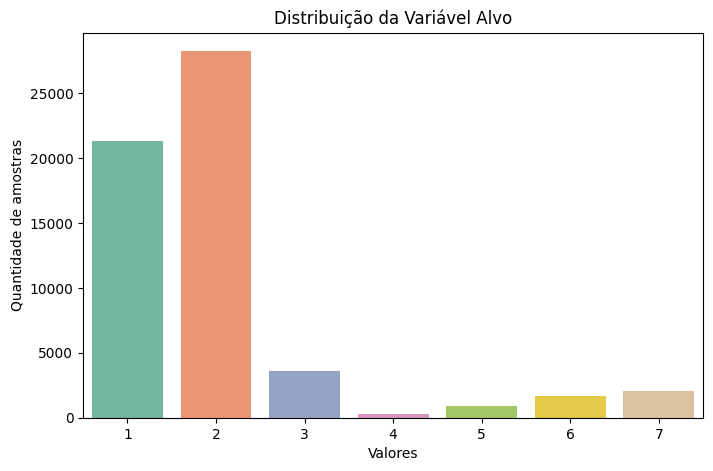

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COLUMN, palette="Set2")

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Valores')
plt.ylabel('Quantidade de amostras')

plt.show()

Dado o gráfico plotado, é possível observar que o dataset é desbalanceado, visto que as classes 1 e 2 dominam a quantidade de amostras com uma frequência de mais de 20000 para as duas, enquanto as outras, 3, 4, 5, 6 e 7, possuem frequência de ocorrência inferior a 5000

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

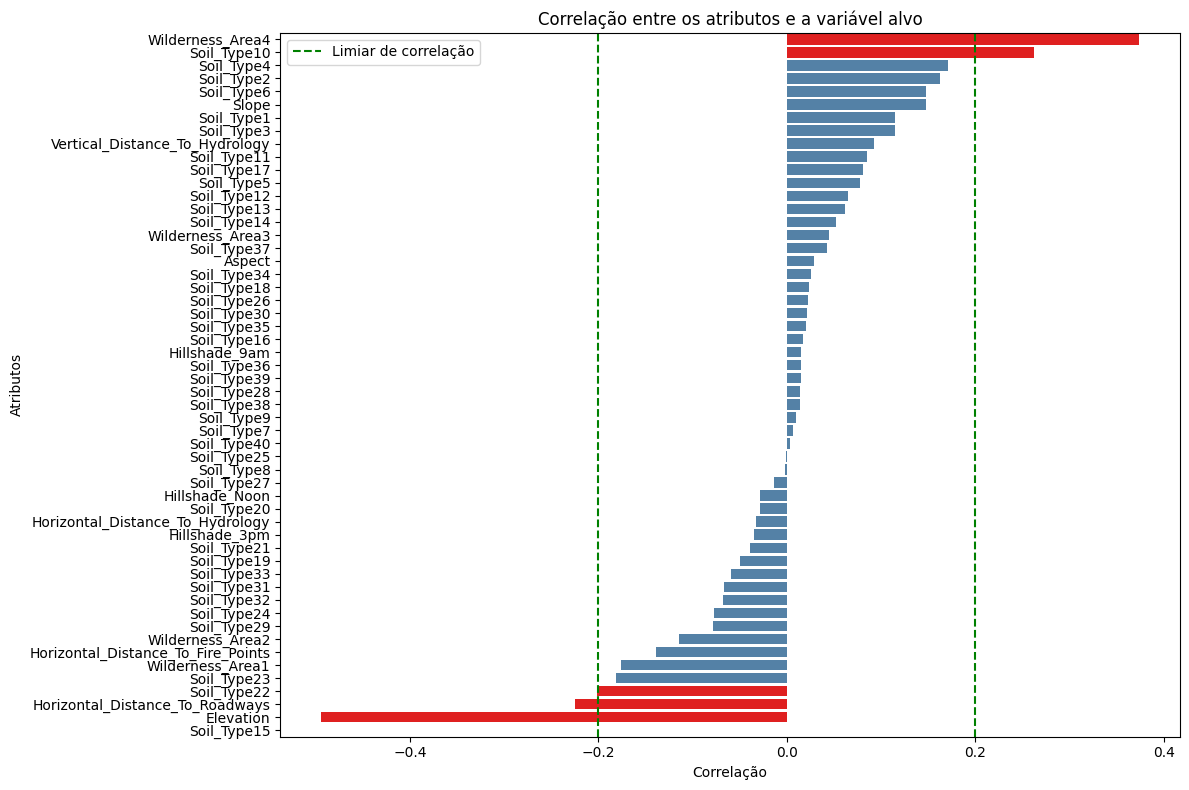

In [37]:
corr_target = (df.corr(numeric_only=True, method='spearman')[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False))

plt.figure(figsize=(12,8))

barras_cores = ['red' if abs(corr) >= 0.2 else 'steelblue' for corr in corr_target]

sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=barras_cores, orient='h')
plt.title("Correlação entre os atributos e a variável alvo")
plt.xlabel("Correlação")
plt.ylabel("Atributos")
plt.axvline(x=0.2, color='green', linestyle='--', label='Limiar de correlação')
plt.axvline(x=-0.2, color='green', linestyle='--')

plt.tight_layout()
plt.legend()
plt.show()

In [39]:
print(corr_target[abs(corr_target) >= 0.2])

Wilderness_Area4                   0.373605
Soil_Type10                        0.262491
Soil_Type22                       -0.201460
Horizontal_Distance_To_Roadways   -0.224560
Elevation                         -0.494117
Name: Cover_Type, dtype: float64


As variáveis mais relevantes para o modelo, considerando o limiar, são: Elevation (−0.49), Wilderness_Area4 (0.37), Horizontal_Distance_To_Roadways (−0.22), Soil_Type10 (0.26) e Soil_Type22 (−0.20).

A Elevation se destaca como o atributo mais correlacionado com a variável alvo, A Wilderness_Area4 apresenta a maior correlação positiva.
Os demais atributos, como os tipos de solo e a distância a rodovias, apresentam correlações moderadas mas ainda acima do limiar adotado, podendo contribuir para a discriminação entre as classes.

A grande maioria dos atributos, especialmente os demais tipos de solo, ficou abaixo do limiar, indicando correlação fraca com a variável alvo e menor relevância preditiva.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

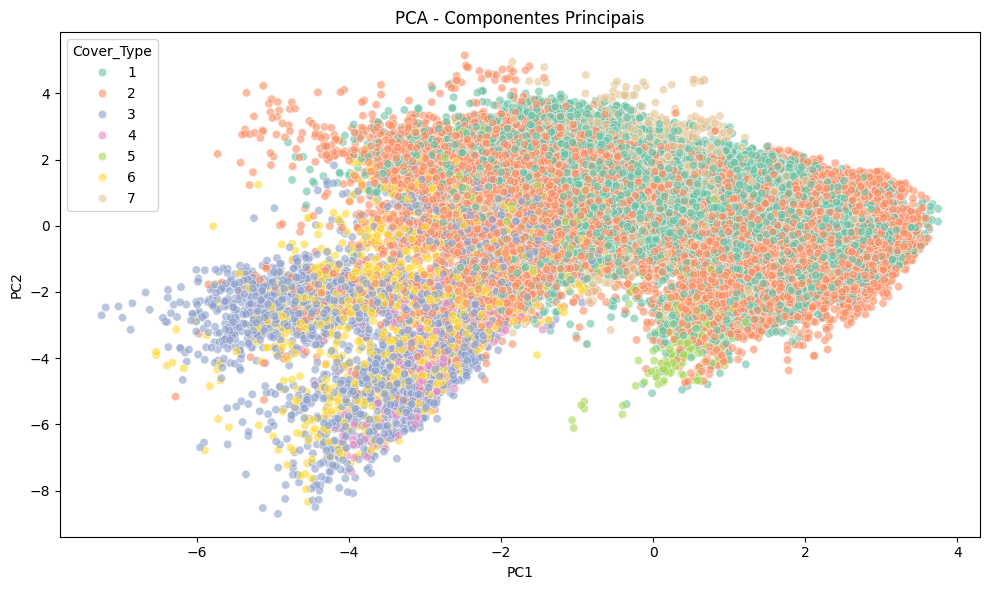

In [22]:
pca = PCA(n_components=2)
scaler = StandardScaler()

Y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

x_scaled = scaler.fit_transform(X)
x_pca = pca.fit_transform(x_scaled)

df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
df_pca[TARGET_COLUMN] = Y.values

plt.figure(figsize=(10,6))

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=TARGET_COLUMN, palette='Set2', alpha=0.6)

plt.title('PCA - Componentes Principais')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


O gráfico gerado indica que há uma separação entre algumas classes, porém ainda havendo uma sobreposição grande em várias delas, observando que, por exemplo, as classes 6 e 3 são separadas de classes como a 5 e 1, porém havendo sobreposição clara entre as próprias classes 6 e 3, além da 1 e 2.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

A validação cruzada é importante pois permite a otimização do modelo, visando minimizar o seu erro, encontrando os pesos ótimos a partir da média dos resultados obtidos a cada fold.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [24]:
acuracias_folds = []

for fold, (train, test) in enumerate(kf.split(x_train), start=1):

  # separação dos conjuntos pro fold atual treino e validacao
  X_fold_train = x_train.iloc[train]
  X_fold_val = x_train.iloc[test]
  y_fold_train = y_train.iloc[train]
  y_fold_val = y_train.iloc[test]

  scaler_fold = StandardScaler()
  X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train)
  X_fold_val_scaled = scaler_fold.transform(X_fold_val)

  model = LogisticRegression(max_iter=1000, random_state=42)
  model.fit(X_fold_train_scaled, y_fold_train)
  y_pred = model.predict(X_fold_val_scaled)

  acuracia = accuracy_score(y_fold_val, y_pred)
  acuracias_folds.append(acuracia)

  print(f"Fold {fold}:")
  print(f"Número de iterações: {model.n_iter_}")
  print(f"Acurácia: {acuracia}")
  print(f"Precisão: {precision_score(y_fold_val, y_pred, average='weighted')}")
  print(f"Recall: {recall_score(y_fold_val, y_pred, average='weighted')}")
  print(f"F1-score: {f1_score(y_fold_val, y_pred, average='weighted')}\n")

print(f"Média final das acurácias: {np.mean(acuracias_folds):.4f}")

Fold 1:
Número de iterações: [184]
Acurácia: 0.7314974182444062
Precisão: 0.7169144621933676
Recall: 0.7314974182444062
F1-score: 0.7220256469588627

Fold 2:
Número de iterações: [179]
Acurácia: 0.7239672977624785
Precisão: 0.7077925534299098
Recall: 0.7239672977624785
F1-score: 0.7122104037743505



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 3:
Número de iterações: [217]
Acurácia: 0.7196643717728055
Precisão: 0.7131852352900053
Recall: 0.7196643717728055
F1-score: 0.7096711629430118

Fold 4:
Número de iterações: [205]
Acurácia: 0.7280550774526678
Precisão: 0.7105073963695798
Recall: 0.7280550774526678
F1-score: 0.7178105278261221



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 5:
Número de iterações: [180]
Acurácia: 0.7265490533562823
Precisão: 0.7145829576781528
Recall: 0.7265490533562823
F1-score: 0.7166900359279709

Média final das acurácias: 0.7259


Observa-se que o modelo, em geral, convergiu bem para cada fold, dado que nenhuma iteração foi superior ao limite fde 1000, estando todas ao redor de 200. As métricas de resultado de cada fold indicam que o modelo teve maior dificuldade para classificar algumas classes minoritárias, algo que pode ser observado pelo warning gerado, que indica que algumas amostras não foram classificadas. O papel do modelo é atuar como um regressor logístico, encontrando uma separação entre as 7 classes do dataset.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [25]:
model_final = LogisticRegression(max_iter=1000, C=0.01, random_state=42)
model_final.fit(x_train_scaled, y_train)

print(f"Iterações: {model_final.n_iter_}")
print(f"Classes:   {model_final.classes_}")

y_prob = model_final.predict_proba(x_test_scaled)

df_probs = pd.DataFrame(y_prob, columns=model_final.classes_)
print(f"Probabilidades previstas:\n {df_probs.head(20)}")




Iterações: [104]
Classes:   [1 2 3 4 5 6 7]
Probabilidades previstas:
            1         2         3         4         5         6         7
0   0.456718  0.523084  0.000064  0.000090  0.003085  0.000088  0.016871
1   0.038392  0.450021  0.152924  0.000451  0.013272  0.344410  0.000530
2   0.224398  0.734051  0.003887  0.000330  0.021610  0.011459  0.004264
3   0.237865  0.745048  0.000941  0.000087  0.011288  0.002022  0.002749
4   0.115367  0.728307  0.007653  0.000130  0.034959  0.113243  0.000341
5   0.598901  0.389038  0.000043  0.000037  0.001486  0.000146  0.010349
6   0.386811  0.597203  0.001345  0.000070  0.004976  0.003742  0.005852
7   0.240762  0.741702  0.000431  0.000106  0.014718  0.000629  0.001651
8   0.473949  0.519709  0.000124  0.000075  0.001559  0.000342  0.004242
9   0.000430  0.049232  0.717409  0.010652  0.002515  0.219762  0.000001
10  0.121720  0.874952  0.000042  0.000032  0.000651  0.000221  0.002382
11  0.294757  0.641785  0.008548  0.000316  0.031258 

Observa-se que o modelo está fazendo em sua maioria previsões com uma boa confiança, de acordo com as 20 primeiras amostras iniciais. Dado que a maior parte dessas amostras foi denotada com probabilidade maior ou próxima a 70%, porém ainda havendo algumas com confiaça menor, alcançando maior estado de dúvida, por volta de 40% a 60%

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [26]:
model_sem_penalty = LogisticRegression(max_iter=1000, penalty=None, random_state=42)
model_sem_penalty.fit(x_train_scaled, y_train)

print(f"Iterações: {model_sem_penalty.n_iter_}")
print(f"Classes: {model_sem_penalty.classes_}")

y_prob_sem_penalty = model_sem_penalty.predict_proba(x_test_scaled)

colunas = [f"P(Classe {c})" for c in model_sem_penalty.classes_]
df_prob_sem_penalty = pd.DataFrame(y_prob_sem_penalty, columns=colunas)

print("\nComparação de confiança entre as questões") #obs a ordem a seguir é 16 e 17
confianca_c001 = y_prob.max(axis=1)[:10]
confianca_sem_penalty = y_prob_sem_penalty.max(axis=1)[:10]

df_comparacao = pd.DataFrame({
    "C=0.01 (Q16)":    confianca_c001,
    "Sem penalty (Q17)": confianca_sem_penalty
})

print(df_comparacao.to_string(float_format="{:.4f}".format))


Iterações: [218]
Classes: [1 2 3 4 5 6 7]

Comparação de confiança entre as questões
   C=0.01 (Q16)  Sem penalty (Q17)
0        0.5231             0.5126
1        0.4500             0.4299
2        0.7341             0.7758
3        0.7450             0.7719
4        0.7283             0.7620
5        0.5989             0.6329
6        0.5972             0.6076
7        0.7417             0.7630
8        0.5197             0.5389
9        0.7174             0.7360


In [27]:
# obs: fazendo uma analise com a metrica de confiança: 70%+ é alto, 40%- é baixa
for nome, probs in [("C=0.01", y_prob), ("Sem penalty", y_prob_sem_penalty)]:
    confianca = probs.max(axis=1)
    alta  = (confianca >= 0.7).mean() * 100
    baixa = (confianca  < 0.4).mean() * 100
    print(f"\n{nome}:")
    print(f"  Alta confiança  (≥70%): {alta:.2f}%")
    print(f"  Baixa confiança (<40%): {baixa:.2f}%")


C=0.01:
  Alta confiança  (≥70%): 50.78%
  Baixa confiança (<40%): 0.57%

Sem penalty:
  Alta confiança  (≥70%): 58.12%
  Baixa confiança (<40%): 0.40%


Com o treinamento sem penalização podemos observar que os resultados tiveram uma piora, apresentando mais casos de baixa confiança, com a probabilidade baixa, caindo em torno de 8% os casos de probabilidade superior a 70%

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

Confiança média C=0.01: 0.7025
Confiança média Sem penalty: 0.7276


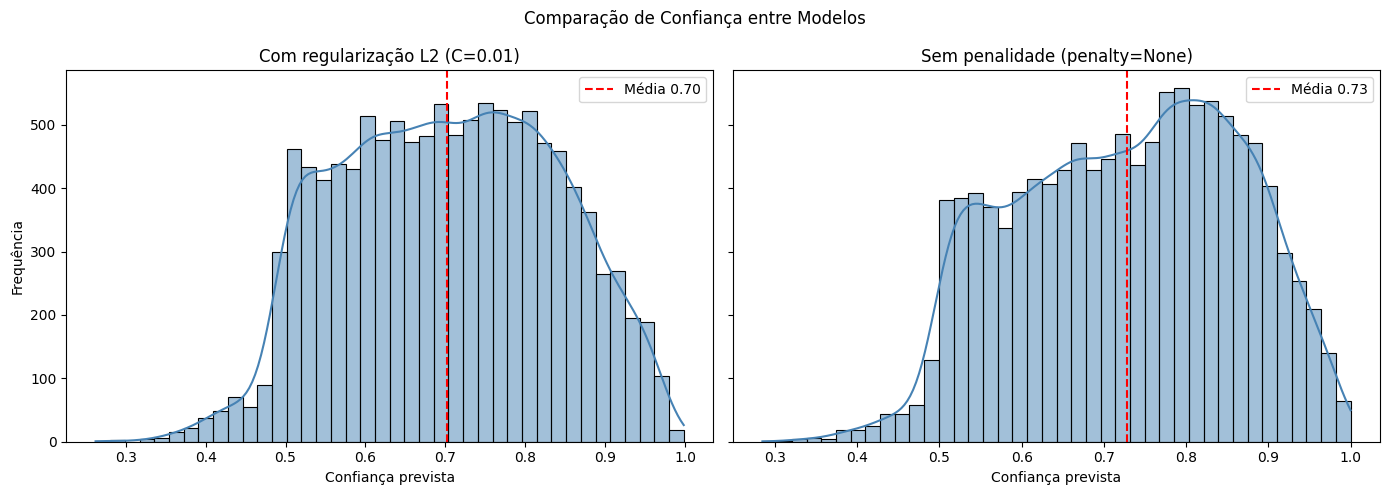

In [28]:
# Confiança de cada uma (mesmo da anterior) - obs: 16 em seguida a 17
confianca_C001 = y_prob.max(axis=1)
confianca_sem_penalty = y_prob_sem_penalty.max(axis=1)

media_C001 = confianca_C001.mean()
media_sem_penalty = confianca_sem_penalty.mean()

print(f"Confiança média C=0.01: {media_C001:.4f}")
print(f"Confiança média Sem penalty: {media_sem_penalty:.4f}")

# Plotando 1 histograma para comparar a confiança dos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, confianca, titulo in zip(axes, [confianca_C001, confianca_sem_penalty], ["Com regularização L2 (C=0.01)", "Sem penalidade (penalty=None)"]):
    sns.histplot(confianca, bins=40, kde=True, ax=ax, color="steelblue")

    # Linha da média tracejada no ponto médio
    ax.axvline(confianca.mean(), color='red', linestyle='--', label=f'Média {confianca.mean():.2f}')

    ax.set_title(titulo)
    ax.set_xlabel("Confiança prevista")
    ax.set_ylabel("Frequência")
    ax.legend()

plt.suptitle("Comparação de Confiança entre Modelos")
plt.tight_layout()
plt.show()

O modelo sem penalidade concentra as probabilidades de forma mais intensa em uma única classe, apresentando distribuição de confiança mais espalhada entre 0.3 e 1.0, com maior frequência de previsões acima de 0.70. Já o modelo com regularização L2 (C=0.01) apresenta distribuição muito mais concentrada em torno de 0.50 a 0.85, com pouca previsão abaixo de 0.50 ou acima de 0.85 — indicando que a regularização suaviza as probabilidades.

A confiança média do modelo sem penalidade (0.73) foi superior à do modelo com regularização (0.70), Isso é esperado, pois sem restrição nos coeficientes o modelo consegue ajustar fronteiras de decisão mais agressivas.

A maior confiança do modelo sem penalidade pode ser um indício de overfitting tornando-se excessivamente confiante mesmo em amostras mais difíceis como as classes minoritárias 4, 5 e 6. A regularização L2 com C=0.01 controla esse comportamento, produzindo probabilidades mais controladas.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [29]:
from sklearn.metrics import classification_report

y_pred_C001 = model_final.predict(x_test_scaled)
y_pred_sem_penalty = model_sem_penalty.predict(x_test_scaled)

# todo: for com zip pra melhorar aqui

classes_c001 = [f"Classe {c}" for c in model_final.classes_]
classes_sem_penalty = [f"Classe {c}" for c in model_sem_penalty.classes_]

print(classification_report(y_test, y_pred_C001, target_names=classes_c001))

print(classification_report(y_test, y_pred_sem_penalty, target_names=classes_sem_penalty))


              precision    recall  f1-score   support

    Classe 1       0.71      0.70      0.70      4163
    Classe 2       0.75      0.81      0.78      5759
    Classe 3       0.62      0.84      0.71       720
    Classe 4       0.40      0.11      0.17        55
    Classe 5       1.00      0.01      0.01       178
    Classe 6       0.51      0.12      0.20       339
    Classe 7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

              precision    recall  f1-score   support

    Classe 1       0.71      0.70      0.70      4163
    Classe 2       0.76      0.80      0.78      5759
    Classe 3       0.64      0.79      0.71       720
    Classe 4       0.58      0.35      0.43        55
    Classe 5       0.50      0.01      0.01       178
    Classe 6       0.47      0.22      0.30       339
    Classe 7       0.70 

Comparando os dois modelos diretamente, as classes que maior apresentam precisão são as majoritárias 1 e 2, que representam a maior parte das amostras, enquanto para as demais os scores de precisão foram menores que 0.70 em ambos os modelos.

No modelo com regularização L2, a Classe 5 apresenta precisão de 1.00, porém com recall de apenas 0.01 — o que indica que o modelo raramente prevê essa classe, e quando prevê acerta, mas deixa de detectar quase todos os casos reais. Isso não é overfitting, mas sim um comportamento conservador causado pela regularização forte, que penaliza muito os coeficientes e faz o modelo evitar prever classes minoritárias.

Para as classes 3, 4 e 6, ambos os modelos apresentam maior dificuldade, com F1-scores baixos. O modelo sem penalidade apresenta uma melhora na Classe 4 (precisão de 0.40 para 0.58) e na Classe 6 (0.51 para 0.47 — leve piora), porém sem ganhos expressivos nas demais.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

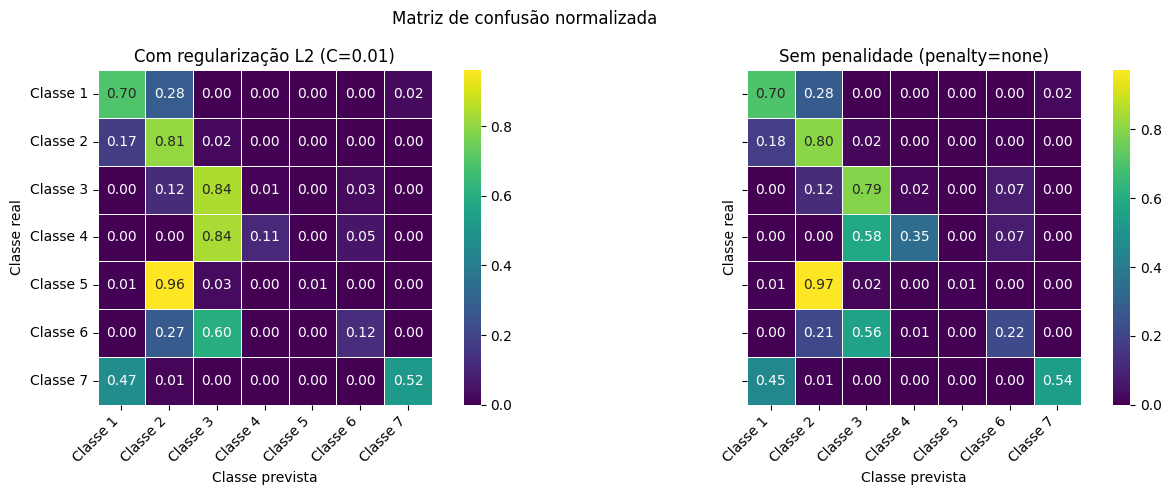

In [30]:
# Matriz de confusão de cada uma (16 e 17)
c_mat_C001 = confusion_matrix(y_test, y_pred_C001, normalize='true')
c_mat_sem_penalty = confusion_matrix(y_test, y_pred_sem_penalty, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

classes = [f"Classe {c}" for c in model_final.classes_]

for ax, mat, titulo in zip(axes, [c_mat_C001, c_mat_sem_penalty], ["Com regularização L2 (C=0.01)", "Sem penalidade (penalty=none)"]):
    sns.heatmap(mat, annot=True, fmt=".2f", square=True, xticklabels=classes, yticklabels=classes, cmap="viridis", ax=ax, linewidths=0.5,)

    ax.set_title(titulo)
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Matriz de confusão normalizada")
plt.tight_layout()
plt.show()

Analisando as matrizes de confusão normalizadas, as classes que apresentam melhor classificação são a Classe 2 e a Classe 3, com valores altos na diagonal em ambos os modelos

As classes com maior confusão são a Classe 7 e a Classe 5. A Classe 7 confunde aproximadamente 47% das amostras com a Classe 1 no modelo com regularização e 45% no modelo sem penalidade. Já a Classe 5 é classificada quase inteira como Classe 2  nos dois modelos, o que indica que essas classes compartilham características muito similares no espaço de atributos

A Classe 6 também apresenta confusão relevante, sendo classificada como Classe 2 em 27% dos casos no modelo com regularização e 21% no modelo sem penalidade, além da confusão com a Classe 6 que aumenta de 0.12 para 0.22 no modelo sem regularização


Comparando os dois modelos, a maior diferença aparece na Classe 4, que cai de 0 84 para 0.58 sem regularização, com aumento grande de confusão com a Classe 3 (de 0.11 para 0.35). Isso indica que o modelo sem penalidade sofre overfitting nas classes minoritárias. Para as classes majoritárias como 1, 2 e 3 os resultados são bastante similares entre os dois modelos, mostrando que a regularização L2 não prejudicou tanto o desempenho geral mas ajuda a estabilizar as classes com menos amostras